# Production Technology

The dataset contains `N = 441` firms observed over `T = 12` years, 1968-1979. There variables are: 
* `lcap`: Log of capital stock, $k_{it}$ 
* `lemp`: log of employment, $\ell_{it}$ 
* `ldsa`: log of deflated sales, $y_{it}$
* `year`: the calendar year of the observation, `year` $ = 1968, ..., 1979$, 
* `firmid`: anonymized indicator variable for the firm, $i = 1, ..., N$, with $N=441$. 

In [2]:
import pandas as pd 
import numpy as np
import seaborn as sns

import w3_LinearModels as lm

In [3]:
dat = pd.read_csv('firms.csv')

In [4]:
dat.sample(5)

,firmid,year,lcap,lemp,ldsa
4943,412,1979,-1.258340,-0.904782,-1.333550
4176,349,1968,0.699119,1.351748,1.173487
3732,312,1968,-1.690910,-1.233630,-0.476697
934,78,1978,0.771830,-0.199512,-0.367553
4984,416,1972,-1.512610,-1.850510,-1.411980


In [5]:
dat.year.unique()

array([1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978,
       1979])

# Descriptives

In [6]:
dat.describe()

,firmid,year,lcap,lemp,ldsa
count,5292.000000,5292.000000,5.292000e+03,5.292000e+03,5.292000e+03
mean,221.000000,1973.500000,-7.125472e-09,-1.252834e-08,4.695767e-09
std,127.317437,3.452379,1.310973e+00,1.180122e+00,1.232499e+00
min,1.000000,1968.000000,-3.864950e+00,-3.382780e+00,-3.551540e+00
25%,111.000000,1970.750000,-9.083267e-01,-7.855270e-01,-9.279720e-01
50%,221.000000,1973.500000,-1.180615e-01,-1.137295e-01,-1.029710e-01
75%,331.000000,1976.250000,9.063340e-01,7.930060e-01,8.562296e-01
max,441.000000,1979.000000,4.103687e+00,3.371332e+00,3.913391e+00


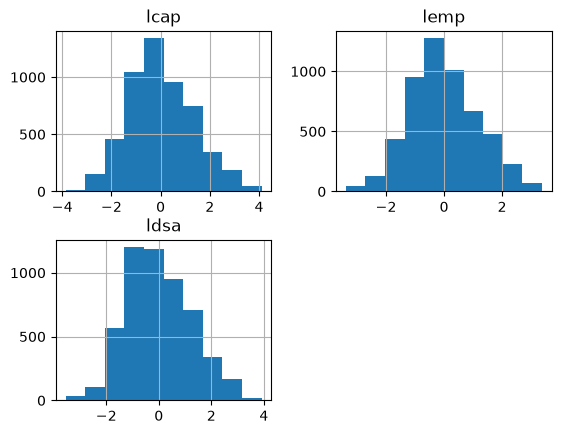

In [7]:
dat[['lcap','lemp','ldsa']].hist();

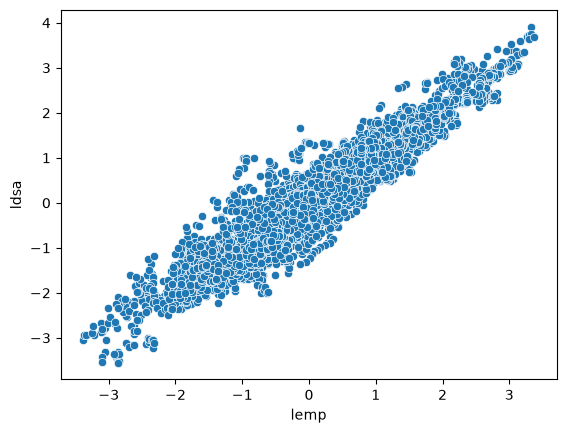

In [8]:
sns.scatterplot(x='lemp', y='ldsa', data=dat); 

# Converting data to numpy format 

In [9]:
dat.ldsa.values.shape

(5292,)

In [10]:
N = dat.firmid.unique().size
T = dat.year.unique().size
assert dat.shape[0] == N*T, f'Error: data is not a balanced panel'
print(f'Data has N={N} and T={T}')

Data has N=441 and T=12


Extract data from `pandas` to `numpy` arrays. 

In [11]:
y = dat.ldsa.values.reshape((N*T,1))

ones = np.ones((N*T,1))
l = dat.lemp.values.reshape((N*T,1))
k = dat.lcap.values.reshape((N*T,1))
X = np.hstack([ones, l, k])

POLS estimator

In [12]:
# Tip: If you want robust standard errors, you can add the argument robust_se=True to the estimate function.
pols_result = lm.estimate(y, X)
pols_robust = lm.estimate(y, X, T=T, robust_se=True)

label_y = "Log deflated sales"
label_x = ["Constant", "Log employment", "Log capital"]

# Then, print the resulting dictionary using the provided print_table() function. The labels should have been provided to you.
lm.print_table((label_y, label_x), pols_result, title="Pooled OLS without robust standard errors")
lm.print_table((label_y, label_x), pols_robust, title="Pooled OLS with robust standard errors")

Pooled OLS without robust standard errors
Dependent variable: Log deflated sales

                Beta              Se            t-values
--------------  ----------------  ------------  ----------------
Constant        [1.53587614e-08]  [0.00497209]  [3.08899704e-06]
Log employment  [0.67477449]      [0.01015271]  [66.46247474]
Log capital     [0.31004076]      [0.00913935]  [33.92372734]
R² = 0.914
σ² = 0.131
Pooled OLS with robust standard errors
Dependent variable: Log deflated sales

                Beta              Se            t-values
--------------  ----------------  ------------  ----------------
Constant        [1.53587614e-08]  [0.01608475]  [9.54864738e-07]
Log employment  [0.67477449]      [0.03656807]  [18.45255895]
Log capital     [0.31004076]      [0.0323601]   [9.58095781]
R² = 0.914
σ² = 0.131


Fixed Effects

In [13]:
def remove_zero_columns(x, label_x):
    """
    The function removes columns from a matrix that are all zeros and returns the updated matrix and
    corresponding labels.
    
    Args:
      x: The parameter `x` is a numpy array representing a matrix with columns that may contain zeros.
      label_x: The parameter `label_x` is a list that contains the labels for each column in the input
    array `x`.
    
    Returns:
      x_nonzero: numpy array of x with columns that are all zeros removed.
      label_nonzero: list of labels for each column in x_nonzero.
    """
    
    # Find the columns that are not all zeros
    nonzero_cols = ~np.all(x == 0, axis=0)
    
    # Remove the columns that are all zeros
    x_nonzero = x[:, nonzero_cols]
    
    # Get the labels for the columns that are not all zeros
    label_nonzero = [label_x[i] for i in range(len(label_x)) if nonzero_cols[i]]
    return x_nonzero, label_nonzero

In [14]:
# Transform the data
Q_T = np.eye(T) - np.ones((T, T)) / T
y_dot = lm.perm(Q_T, y)
X_dot = lm.perm(Q_T, X)

# Remove the columns that are only zeroes
# Remove the demeaned constant (first column)
X_dot = X_dot[:, 1:]
label_X_dot = label_x[1:]

# Estimate
fe_result = lm.estimate(y_dot, X_dot, transform='fe', T=T, robust_se=True)
lm.print_table((label_y, label_X_dot), fe_result, title="Fixed Effects", floatfmt='.4f')

Fixed Effects
Dependent variable: Log deflated sales

                Beta          Se            t-values
--------------  ------------  ------------  -------------
Log employment  [0.69422625]  [0.04165182]  [16.66737035]
Log capital     [0.15461952]  [0.02994777]  [5.16297184]
R² = 0.477
σ² = 0.018


First difference

In [15]:
# Transform the data
D_T = -np.eye(T)[:-1, :] + np.eye(T)[1:, :]
y_diff = lm.perm(D_T, y)
X_diff = lm.perm(D_T, X)

# Remove the columns that are only zeroes
X_diff = np.delete(X_diff, 0, axis=1)

# Estimate
fd_result = lm.estimate(y_diff, X_diff, transform='fd', T=T - 1, robust_se=True)
lm.print_table((label_y, label_X_dot), fd_result, title="First Difference", floatfmt='.4f')

First Difference
Dependent variable: Log deflated sales

                Beta          Se            t-values
--------------  ------------  ------------  -------------
Log employment  [0.54866574]  [0.02915467]  [18.81913795]
Log capital     [0.06296038]  [0.02323536]  [2.70967879]
R² = 0.165
σ² = 0.014


Random effects

In [16]:
# Calculate firm-level time averages
P_T = np.ones((1, T)) / T
y_mean = lm.perm(P_T, y)
X_mean = lm.perm(P_T, X)

# Estimate
be_result = lm.estimate(y_mean, X_mean, transform='be')

lm.print_table(
    (label_y, label_x),
    be_result,
    title="Between Estimator",
    floatfmt='.4f'
)

# Calculate lambda
sigma2_u = fe_result['sigma2']
sigma2_w = be_result['sigma2']
sigma2_c = sigma2_w - sigma2_u / T
_lambda = 1 - np.sqrt(sigma2_u / (sigma2_u + T * sigma2_c))

# Print lambda
print(f'Lambda is approximately equal to {_lambda.item():.4f}.')

# Transform the data
C_T = np.eye(T) - _lambda * P_T
y_re = lm.perm(C_T, y)
X_re = lm.perm(C_T, X)

# Estimate
re_result = lm.estimate(
    y_re, X_re, transform='re', T=T, robust_se=True
)

lm.print_table(
    (label_y, label_x),
    re_result,
    title="Random Effects",
    floatfmt='.4f'
)

Between Estimator
Dependent variable: Log deflated sales

                Beta              Se            t-values
--------------  ----------------  ------------  ----------------
Constant        [1.53262154e-08]  [0.0161381]   [9.49691207e-07]
Log employment  [0.66721391]      [0.03429133]  [19.45722025]
Log capital     [0.31876658]      [0.03087923]  [10.32301086]
R² = 0.923
σ² = 0.115
Lambda is approximately equal to 0.8873.
Random Effects
Dependent variable: Log deflated sales

                Beta              Se            t-values
--------------  ----------------  ------------  ----------------
Constant        [1.51292733e-08]  [0.01680917]  [9.00060935e-07]
Log employment  [0.71968578]      [0.03353037]  [21.46370045]
Log capital     [0.19886888]      [0.02610732]  [7.61736048]
R² = 0.642
σ² = 0.018


Testing
- Serial correlation (FD.3 and FE.3)

In [17]:
# Make function to calculate the serial correlation
def serial_corr(y, X, T):
    # Calculate the residuals
    b_hat = lm.est_ols(y, X)
    e = y - X@b_hat
    
    # Create a lag transformation matrix
    L_T = np.eye(T, k=-1)
    L_T = L_T[1:]

    # Lag residuals
    e_l = lm.perm(L_T, e)

    # Create a transformation matrix that removes the first observation of each individual
    I_T = np.eye(T, k=0)
    I_T = I_T[1:]
    
    # Remove first observation of each individual
    e = lm.perm(I_T, e)
    
    # Calculate the serial correlation
    return lm.estimate(e, e_l, T=T-1, robust_se=True)

In [18]:
# Estimate serial correlation
corr_result = serial_corr(y_diff, X_diff, T-1)

# Print results
label_ye = 'OLS residual, e\u1d62\u209c'
label_e = ['e\u1d62\u209c\u208B\u2081']
lm.print_table(
    (label_ye, label_e), corr_result, 
    title='Serial Correlation', floatfmt='.4f'
)

# 95% confidence interval for the FD residual correlation coefficient
rho_hat = corr_result['b_hat'].item()
rho_se = corr_result['se'].item()

rho_ci_lower = rho_hat - 1.96 * rho_se
rho_ci_upper = rho_hat + 1.96 * rho_se

print(f"95% confidence interval: [{rho_ci_lower:.4f}, {rho_ci_upper:.4f}]")

Serial Correlation
Dependent variable: OLS residual, eᵢₜ

       Beta           Se            t-values
-----  -------------  ------------  --------------
eᵢₜ₋₁  [-0.19865124]  [0.01689828]  [-11.75570752]
R² = 0.039
σ² = 0.014
95% confidence interval: [-0.2318, -0.1655]


- Strict exogeneity (FE.1) and Wald test

In [19]:
from scipy.stats import chi2
# Lead transformation matrix
F_T = np.eye(T, k=1)
F_T = F_T[:-1]

# Next year's labour and capital
labour_lead = lm.perm(F_T, X[:, 1].reshape(-1, 1))
capital_lead = lm.perm(F_T, X[:, 2].reshape(-1, 1))

# Remove the last observed year for every individual
I_T = np.eye(T, k=0)
I_T = I_T[:-1]

X_exo = lm.perm(I_T, X)
y_exo = lm.perm(I_T, y)

# Add leads of labour and capital
X_exo = np.hstack((X_exo, labour_lead, capital_lead))

# Within-transform over the remaining 11 periods
Q_T = np.eye(T - 1) - np.ones((T - 1, T - 1)) / (T - 1)
yw_exo = lm.perm(Q_T, y_exo)
Xw_exo = lm.perm(Q_T, X_exo)

# Remove the demeaned constant
Xw_exo = Xw_exo[:, 1:]

# Estimate model
exo_test = lm.estimate(
    yw_exo, Xw_exo, T=T-1, transform='fe', robust_se=True
)

# Print results
label_exo = [
    'Log employment',
    'Log capital',
    'Employment lead',
    'Capital lead'
]

lm.print_table(
    (label_y, label_exo),
    exo_test,
    title='Exogeneity test',
    floatfmt='.4f'
)

# Individual 95% confidence intervals
b_hat = exo_test['b_hat'].flatten()
se = exo_test['se'].flatten()

ci_lower = b_hat - 1.96 * se
ci_upper = b_hat + 1.96 * se

for name, lower, upper in zip(label_exo, ci_lower, ci_upper):
    print(f"{name}: [{lower:.4f}, {upper:.4f}]")

# Wald test for joint significance of the two lead coefficients
# Extract the two lead coefficients and their covariance matrix
# Column order: labour, capital, labour lead, capital lead
b_leads = exo_test['b_hat'][2:4].reshape(2, 1)
cov_leads = exo_test['cov'][2:4, 2:4]

# Joint Wald statistic
W = (b_leads.T @ np.linalg.solve(cov_leads, b_leads)).item()

# Two restrictions => two degrees of freedom
df = 2
crit_val = chi2.ppf(0.95, df)
p_val = chi2.sf(W, df)

print(f"Wald statistic: {W:.4f}")
print(f"5% critical value: {crit_val:.4f}")
print(f"P-value: {p_val:.6g}")

Exogeneity test
Dependent variable: Log deflated sales

                 Beta          Se            t-values
---------------  ------------  ------------  -------------
Log employment   [0.54082746]  [0.04307245]  [12.55622725]
Log capital      [0.02799744]  [0.03754258]  [0.74575146]
Employment lead  [0.14194843]  [0.02829232]  [5.01720705]
Capital lead     [0.16672914]  [0.04566195]  [3.65137998]
R² = 0.478
σ² = 0.016
Log employment: [0.4564, 0.6252]
Log capital: [-0.0456, 0.1016]
Employment lead: [0.0865, 0.1974]
Capital lead: [0.0772, 0.2562]
Wald statistic: 44.1107
5% critical value: 5.9915
P-value: 2.63927e-10


- Time Series dummies and fixed effects

In [20]:
# Year indicators: 1968 is the reference year
dummy_block = np.eye(T, k=-1)[:, :-1]
dummy_matrix = np.tile(dummy_block, (N, 1))

# Interact year indicators with log labour and log capital
labour_dummies = dummy_matrix * X[:, 1].reshape(-1, 1)
capital_dummies = dummy_matrix * X[:, 2].reshape(-1, 1)

# Within-transform using all 12 periods
Q_T = np.eye(T) - np.ones((T, T)) / T

y_dot_interactions = lm.perm(Q_T, y)
X_dot_base = lm.perm(Q_T, X[:, 1:])
labour_demean = lm.perm(Q_T, labour_dummies)
capital_demean = lm.perm(Q_T, capital_dummies)

# Combine baseline regressors and interactions
X_demean_dummies = np.hstack([
    X_dot_base,
    labour_demean,
    capital_demean
])

# Labels in the same order as the columns
label_x_interactions = (
    ['Log employment', 'Log capital']
    + [f'Employment × {year}' for year in range(1969, 1980)]
    + [f'Capital × {year}' for year in range(1969, 1980)]
)

# Estimate model
int_result = lm.estimate(
    y_dot_interactions,
    X_demean_dummies,
    transform='fe',
    T=T,
    robust_se=True
)

# Print results
lm.print_table(
    (label_y, label_x_interactions),
    int_result,
    title='FE with year interactions',
    floatfmt='.4f'
)

FE with year interactions
Dependent variable: Log deflated sales

                   Beta           Se            t-values
-----------------  -------------  ------------  -------------
Log employment     [0.70148294]   [0.04577179]  [15.32566269]
Log capital        [0.15004271]   [0.03062647]  [4.89911908]
Employment × 1969  [0.00157943]   [0.01389647]  [0.11365668]
Employment × 1970  [-0.01892058]  [0.01615765]  [-1.17099834]
Employment × 1971  [-0.00924344]  [0.0177328]   [-0.52126231]
Employment × 1972  [-0.01043124]  [0.01769028]  [-0.58965961]
Employment × 1973  [-0.02190357]  [0.01799656]  [-1.21709743]
Employment × 1974  [-0.06061164]  [0.02383289]  [-2.5431926]
Employment × 1975  [0.0172494]    [0.02291009]  [0.75291702]
Employment × 1976  [0.0077696]    [0.02521164]  [0.30817498]
Employment × 1977  [0.0134871]    [0.02565812]  [0.52564661]
Employment × 1978  [0.02587603]   [0.02726289]  [0.94913021]
Employment × 1979  [0.00338541]   [0.02951773]  [0.11469067]
Capital × 1969   

Exogeneity test for the FD model

In [21]:
# Current levels aligned with the differenced observations:
# drop 1968 for each firm
current_T = np.eye(T)[1:, :]
X_current_fd = lm.perm(current_T, X[:, 1:])

# Columns: change in labour, change in capital,
#          current labour, current capital
X_fd_exo = np.hstack([X_diff, X_current_fd])

fd_exo_result = lm.estimate(
    y_diff,
    X_fd_exo,
    transform='fd',
    T=T - 1,
    robust_se=True
)

label_fd_exo = [
    'Change in log employment',
    'Change in log capital',
    'Current log employment',
    'Current log capital'
]

lm.print_table(
    (label_y, label_fd_exo),
    fd_exo_result,
    title='FD exogeneity test',
    floatfmt='.4f'
)

# Joint null: both coefficients on current levels are zero
b_levels_fd = fd_exo_result['b_hat'][2:4].reshape(2, 1)
cov_levels_fd = fd_exo_result['cov'][2:4, 2:4]

W_fd_exo = (
    b_levels_fd.T
    @ np.linalg.solve(cov_levels_fd, b_levels_fd)
).item()

p_fd_exo = chi2.sf(W_fd_exo, df=2)
crit_fd_exo = chi2.ppf(0.95, df=2)

print(f"Wald statistic: {W_fd_exo:.4f}")
print(f"5% critical value: {crit_fd_exo:.4f}")
print(f"P-value: {p_fd_exo:.6g}")
print(fd_exo_result['cov'])

FD exogeneity test
Dependent variable: Log deflated sales

                          Beta           Se            t-values
------------------------  -------------  ------------  -------------
Change in log employment  [0.54384673]   [0.02977181]  [18.26716858]
Change in log capital     [0.06113151]   [0.02348325]  [2.60319601]
Current log employment    [0.00445267]   [0.00296428]  [1.50210937]
Current log capital       [-0.00463472]  [0.00258915]  [-1.79005259]
R² = 0.165
σ² = 0.014
Wald statistic: 3.4056
5% critical value: 5.9915
P-value: 0.182174
[[ 8.86360845e-04 -1.70490470e-04 -1.69463567e-05  2.08228287e-05]
 [-1.70490470e-04  5.51463239e-04 -1.22438938e-05  1.19153901e-05]
 [-1.69463567e-05 -1.22438938e-05  8.78695988e-06 -7.14368011e-06]
 [ 2.08228287e-05  1.19153901e-05 -7.14368011e-06  6.70372281e-06]]


In [24]:
A = np.array([
    [ 8.38423492e-04, -1.85254007e-04, -1.13550245e-05,  1.72752446e-05],
    [-1.85254007e-04,  5.38824661e-04, -1.49658541e-05,  1.42976796e-05],
    [-1.13550245e-05, -1.49658541e-05,  8.33568305e-06, -7.03667930e-06],
    [ 1.72752446e-05,  1.42976796e-05, -7.03667930e-06,  6.86150616e-06]
])

Covariance_diff = np.array([A - fd_exo_result['cov']])

print(Covariance_diff)

[[[-4.79373526e-05 -1.47635374e-05  5.59133223e-06 -3.54758407e-06]
  [-1.47635374e-05 -1.26385784e-05 -2.72196030e-06  2.38228952e-06]
  [ 5.59133223e-06 -2.72196030e-06 -4.51276826e-07  1.07000814e-07]
  [-3.54758407e-06  2.38228952e-06  1.07000814e-07  1.57783354e-07]]]


Testing $H_0 : \beta_L + \beta_K = 1$

In [22]:
from scipy.stats import norm

# Both baseline models have coefficient order: labour, capital
R_crs = np.array([[1.0, 1.0]])
critical_crs = norm.ppf(0.975)

crs_rows = []

for model_name, result in [('FE', fe_result), ('FD', fd_result)]:
    b_crs = np.asarray(result['b_hat']).reshape(-1, 1)
    cov_crs = np.asarray(result['cov'])

    # Estimated sum and its robust standard error
    sum_crs = (R_crs @ b_crs).item()
    se_crs = np.sqrt((R_crs @ cov_crs @ R_crs.T).item())

    # Two-sided test of H0: beta_L + beta_K = 1
    t_crs = (sum_crs - 1.0) / se_crs
    p_crs = 2 * norm.sf(abs(t_crs))

    # 95% confidence interval for the sum
    lower_crs = sum_crs - critical_crs * se_crs
    upper_crs = sum_crs + critical_crs * se_crs

    crs_rows.append({
        'Estimator': model_name,
        'Sum of elasticities': sum_crs,
        'Robust SE': se_crs,
        't-statistic': t_crs,
        'P-value': p_crs,
        '95% CI lower': lower_crs,
        '95% CI upper': upper_crs,
        'Reject at 5%': abs(t_crs) > critical_crs
    })

crs_results = pd.DataFrame(crs_rows).set_index('Estimator')

print(crs_results.to_string(float_format=lambda value: f'{value:.6g}'))

           Sum of elasticities  Robust SE  t-statistic     P-value  95% CI lower  95% CI upper  Reject at 5%
Estimator                                                                                                   
FE                    0.848846  0.0343152     -4.40487 1.05846e-05      0.781589      0.916102          True
FD                    0.611626  0.0317076     -12.2486  1.7094e-34       0.54948      0.673772          True
